# Creating the model with CO2 limit

in this notebook, the model created in model.ipynb will be imported and global_constraints of CO2 limit will be applied.

## Importing packages

In [1]:
import linopy
import pypsa

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

import cartopy
import cartopy.crs as ccrs

import networkx as nx

import atlite
from atlite.gis import ExclusionContainer, shape_availability
from rasterio.plot import show
from rasterio.crs import CRS
import rasterio as rio

from pathlib import Path
import xarray as xr

## Importing the base model

In [2]:
n_no_co2 = pypsa.Network("pypsa_model_n.nc") # the model without CO2 limits is imported

INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.5)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks


In [3]:
n_no_co2.global_constraints

attribute,type,investment_period,bus,carrier_attribute,sense,constant,mu
name,,,,,,,


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x12c4f8fb0>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x12c4fbf20>},
 'flows': {}}

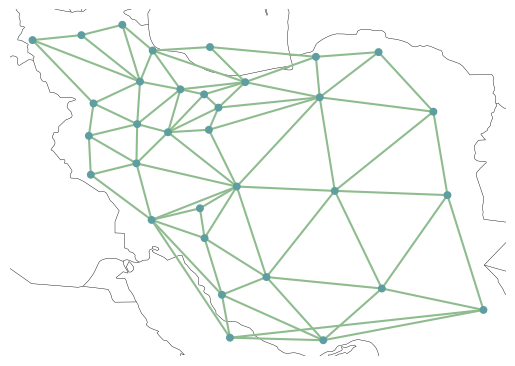

In [4]:
n_no_co2.plot()

## Adding co2 limit constraint

In [5]:
n_no_co2.add(
    "GlobalConstraint",
    "CO2Limit",
    carrier_attribute="co2_emissions",
    sense="<=",
    constant=0, # the CO2 limit is 0 --> 100% renewable system
)

In [6]:
n_no_co2.global_constraints

,type,investment_period,bus,carrier_attribute,sense,constant,mu
name,,,,,,,
CO2Limit,primary_energy,NaN,,co2_emissions,<=,0.0,0.0


## Solving the model

In [7]:
# solve the model with co2 limit
n_no_co2.optimize(
    #snapshots=n_no_co2.snapshots[:168],  # 1 week
    solver_name="gurobi",
    method=2,
    crossover=0,
    BarConvTol=1.0e-05,
    AggFill=0,
    PreDual=0,
    GURO_PAR_BARDENSETHRESH=200,
    log_to_console=False
)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - method: 2
 - crossover: 0
 - BarConvTol: 1e-05
 - AggFill: 0
 - PreDual: 0
 - GURO_PAR_BARDENSETHRESH: 200
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 49.14it/s]
INFO:linopy.io: Writing time: 3.99s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2750042


INFO:gurobipy:Set parameter LicenseID to value 2750042


...

Set parameter GURO_PAR_BARDENSETHRESH to value 200


INFO:gurobipy:Set parameter GURO_PAR_BARDENSETHRESH to value 200


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 25.2.0 25C56)
INFO:gurobipy:
INFO:gurobipy:CPU model: Apple M4 Pro
INFO:gurobipy:Thread count: 14 physical cores, 14 logical processors, using up to 14 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:Method  2
INFO:gurobipy:BarConvTol  1e-05
INFO:gurobipy:Crossover  0
INFO:gurobipy:AggFill  0
INFO:gurobipy:PreDual  0
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:GURO_PAR_BARDENSETHRESH  200
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 5037396 rows, 2199091 columns and 10827180 nonzeros (Min)
INFO:gurobipy:Model fingerprint: 0x143c2769
INFO:gurobipy:Model has 304011 linear objective coefficients
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [2e-10, 7e+02]
INFO:gurobipy:  Objective range  [1e-02, 2e+05]
INFO:gurobipy:  Bounds range     [0e+00, 0e+00]
INFO:gurobipy:  RHS range        [2e+00, 4e+05]
I

('ok', 'optimal')

In [8]:
n_no_co2.objective / 1e6 # in Mio. €

25119.51110315625

In [10]:
n_no_co2.statistics.energy_balance.iplot()

## Exporting the model into a .nc file

In [11]:
n_no_co2.export_to_netcdf("pypsa_model_n_no_co2.nc")

INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'pypsa_model_n_no_co2.nc contains: links, storage_units, buses, global_constraints, generators, loads, sub_networks, carriers


<xarray.Dataset> Size: 28MB
Dimensions:                            (snapshots: 2920, links_i: 81,
                                        links_t_p0_i: 81, links_t_p1_i: 81,
                                        storage_units_i: 186,
                                        storage_units_t_p_i: 186,
                                        storage_units_t_p_dispatch_i: 186,
                                        storage_units_t_p_store_i: 186,
                                        ...
                                        global_constraints_i: 1,
                                        generators_i: 114,
                                        generators_t_p_max_pu_i: 64,
                                        generators_t_p_i: 75, loads_i: 31,
                                        loads_t_p_set_i: 31, loads_t_p_i: 31,
                                        sub_networks_i: 33, carriers_i: 10)
Coordinates: (12/21)
  * snapshots                          (snapshots) int64 23kB 0 1 ... 2918 2919
  * links_i                            (links_i) object 648B 'line_Alborz__Ma...
  * links_t_p0_i                       (links_t_p0_i) object 648B 'line_Albor...
  * links_t_p1_i                       (links_t_p1_i) object 648B 'line_Albor...
  * storage_units_i                    (storage_units_i) object 1kB 'battery_...
  * storage_units_t_p_i                (storage_units_t_p_i) object 1kB 'batt...
    ...                                 ...
  * generators_t_p_i                   (generators_t_p_i) object 600B 'exist_...
  * loads_i                            (loads_i) object 248B 'load_Alborz' .....
  * loads_t_p_set_i                    (loads_t_p_set_i) object 248B 'load_Al...
  * loads_t_p_i                        (loads_t_p_i) object 248B 'load_Alborz...
  * sub_networks_i                     (sub_networks_i) object 264B '0' ... '32'
  * carriers_i                         (carriers_i) object 80B 'CCGT' ... 'el...
Data variables: (12/56)
    snapshots_snapshot                 (snapshots) datetime64[ns] 23kB 2025-0...
    snapshots_objective                (snapshots) float64 23kB 1.0 1.0 ... 1.0
    snapshots_stores                   (snapshots) float64 23kB 1.0 1.0 ... 1.0
    snapshots_generators               (snapshots) float64 23kB 1.0 1.0 ... 1.0
    links_bus0                         (links_i) object 648B 'Alborz' ... 'We...
    links_bus1                         (links_i) object 648B 'Markazi' ... 'Z...
    ...                                 ...
    loads_t_p                          (snapshots, loads_t_p_i) float64 724kB ...
    sub_networks_carrier               (sub_networks_i) object 264B 'electric...
    sub_networks_slack_bus             (sub_networks_i) object 264B 'Alborz' ...
    sub_networks_obj                   (sub_networks_i) float64 264B nan ... nan
    carriers_co2_emissions             (carriers_i) float64 80B 0.198 ... 0.0
    carriers_color                     (carriers_i) object 80B 'red' ... 'black'
Attributes:
    network__linearized_uc:       0
    network__multi_invest:        0
    network__objective:           25119511103.15625
    network__objective_constant:  0.0
    network_name:                 Unnamed Network
    network_pypsa_version:        1.0.5
    network_srid:                 4326
    crs:                          {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Wor...
    meta:                         {}